<a href="https://colab.research.google.com/github/Pinery-lee/PaddleRS/blob/develop/train_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
print(torch.__version__)
# 检查是否启用了 GPU
torch.cuda.is_available()

2.6.0+cu124


True

In [7]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import VOCSegmentation

# 定义数据预处理
# 数据预处理，图像和标签都要转换为 tensor
class SegmentationTransform:
    def __init__(self):
        self.transform_image = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        self.transform_target = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor()
        ])

    def __call__(self, image, target):
        image = self.transform_image(image)
        target = self.transform_target(target)
        return image, target

transform = SegmentationTransform()
# 加载数据集
train_data = VOCSegmentation(root='./data', year='2012', image_set='train', download=True, transform=transform.transform_image, # 用于图像
                            target_transform=transform.transform_target)
train_loader = DataLoader(train_data, batch_size=4, shuffle=True)

# 加载预训练模型
model = torchvision.models.segmentation.deeplabv3_resnet101(pretrained=True)
model.eval()  # 评估模式



DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [14]:
import torch.optim as optim
import torch.nn.functional as F
from torch import nn

# 选择 GPU 或 CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 训练循环（这里只做简化的训练）
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, targets in train_loader:
        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()

        outputs = model(images)['out']

        targets = targets.squeeze(1).type(torch.long)
        loss = criterion(outputs, targets)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}")


Epoch 1/10, Loss: 0.2029659331577723
Epoch 2/10, Loss: 0.17984825739117918
Epoch 3/10, Loss: 0.15858085881002615
Epoch 4/10, Loss: 0.1437473804410038
Epoch 5/10, Loss: 0.1317779428625856
Epoch 6/10, Loss: 0.13752737878490992
Epoch 7/10, Loss: 0.12220710679848011
Epoch 8/10, Loss: 0.11828474459223083
Epoch 9/10, Loss: 0.10784079416405634
Epoch 10/10, Loss: 0.10219124437925595


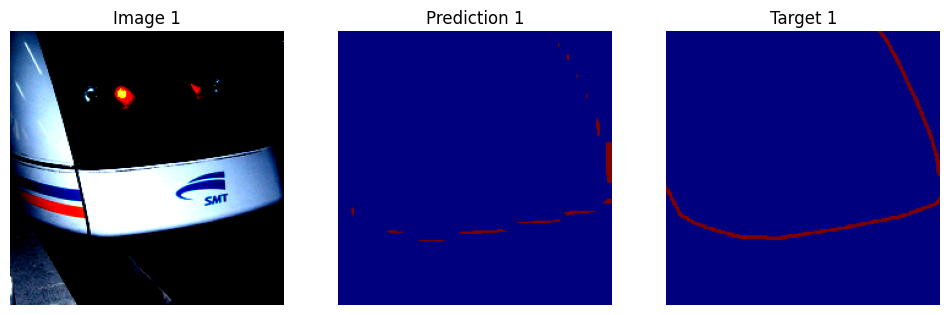

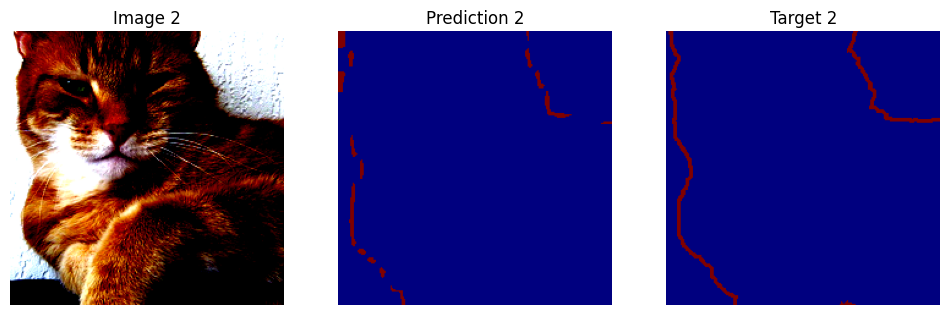

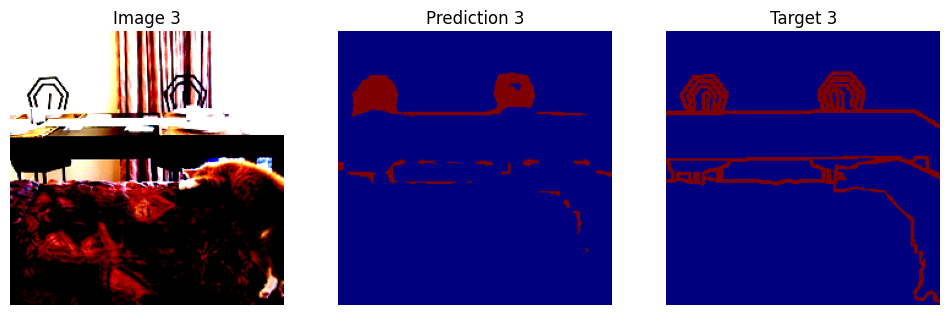

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import transforms
from PIL import Image

# 定义显示函数
def display_image_predictions(model, dataloader, device):
    model.eval()  # 确保模型处于评估模式
    images, targets = next(iter(dataloader))  # 获取一个批次的数据
    images, targets = images.to(device), targets.to(device)

    with torch.no_grad():  # 关闭梯度计算以节省内存
        outputs = model(images)['out']  # 获取模型预测结果

    # 获取预测的类别（最大值索引）
    _, predicted = torch.max(outputs, 1)

    # 准备显示的图像和标签
    images = images.cpu().numpy()
    predicted = predicted.cpu().numpy()
    targets = targets.cpu().numpy()

    # 选择几张图片来展示
    num_display = 3
    for i in range(num_display):
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))

        # 转换为图像
        image = np.transpose(images[i], (1, 2, 0))  # 转换维度 (C, H, W) -> (H, W, C)
        ax[0].imshow(image)
        ax[0].set_title(f"Image {i+1}")
        ax[0].axis('off')

        # 显示预测结果
        ax[1].imshow(predicted[i], cmap='jet')
        ax[1].set_title(f"Prediction {i+1}")
        ax[1].axis('off')

        # 显示真实标签
        # Remove the extra dimension from targets using squeeze() and convert to int
        ax[2].imshow(targets[i].squeeze().astype(int), cmap='jet')
        ax[2].set_title(f"Target {i+1}")
        ax[2].axis('off')

        plt.show()

# 展示一些训练好的模型结果
display_image_predictions(model, train_loader, device)